# HyWindSea SANTANDER — SWAN case selection

The same technique as `00`, one rung down. There the question was which *days* to
simulate with WRF; here it is which *hours* of those days to simulate with SWAN.

The PCA fitted here is not only a step towards the selection: it is the predictor
of the whole metamodel, loaded again by `03`, `04` and `05`.

**Reads** `inputs/wind_era5_full.nc`, `outputs/SANTANDER/times/times_wrf_santander.txt`
**Writes** `outputs/SANTANDER/pca/pca_era5.pkl`, `outputs/SANTANDER/times/times{NUM_TIMES}.txt`

In [1]:
import os

import numpy as np
import pandas as pd
import xarray as xr
from bluemath_tk.datamining.mda import MDA
from bluemath_tk.datamining.pca import PCA

In [ ]:
SITE = "SANTANDER"
NUM_TIMES = 10  # cases to run with SWAN

PCA_DIR = f"outputs/{SITE}/pca"
TIMES_DIR = f"outputs/{SITE}/times"

os.makedirs(PCA_DIR, exist_ok=True)
os.makedirs(TIMES_DIR, exist_ok=True)

## ERA5 winds on the simulated days

The 365 days chosen in `00`, at their full hourly resolution: 8,760 wind fields,
one per hour WRF simulated.

In [ ]:
days = pd.DatetimeIndex(np.loadtxt(f"{TIMES_DIR}/times_wrf_santander.txt", dtype=str))
hours = pd.DatetimeIndex(
    np.concatenate(
        [(day + pd.to_timedelta(np.arange(24), unit="h")).values for day in days]
    )
)

era5 = xr.open_dataset("inputs/wind_era5_full.nc").sel(time=hours)

print(f"{len(days)} days x 24 h = {era5.sizes['time']:,} hourly wind fields")
era5

365 days x 24 h = 8,760 hourly wind fields


<xarray.Dataset> Size: 1MB
Dimensions:  (time: 8760, lat: 4, lon: 5)
Coordinates:
  * lat      (lat) float64 32B 43.0 43.25 43.5 43.75
  * lon      (lon) float64 40B 355.8 356.0 356.2 356.5 356.8
  * time     (time) datetime64[ns] 70kB 1987-10-15 ... 2014-04-02T23:00:00
Data variables:
    u10      (time, lat, lon) float32 701kB ...
    v10      (time, lat, lon) float32 701kB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-12-04T16:25 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## PCA

In [ ]:
pca = PCA(n_components=0.995)

pca.fit_transform(
    data=era5,
    vars_to_stack=["u10", "v10"],
    coords_to_stack=["lat", "lon"],
    pca_dim_for_rows="time",
)

print(
    f"{pca.pca.n_components_} PCs · "
    f"{pca.cumulative_explained_variance_ratio[-1]:.1%} of the variance"
)

2026-08-27 10:48:25,456 - PCA - WARNING - Using 20 out of 20 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-08-27 10:48:25,458 - PCA - WARNING - Using 20 out of 20 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


11 PCs · 99.6% of the variance


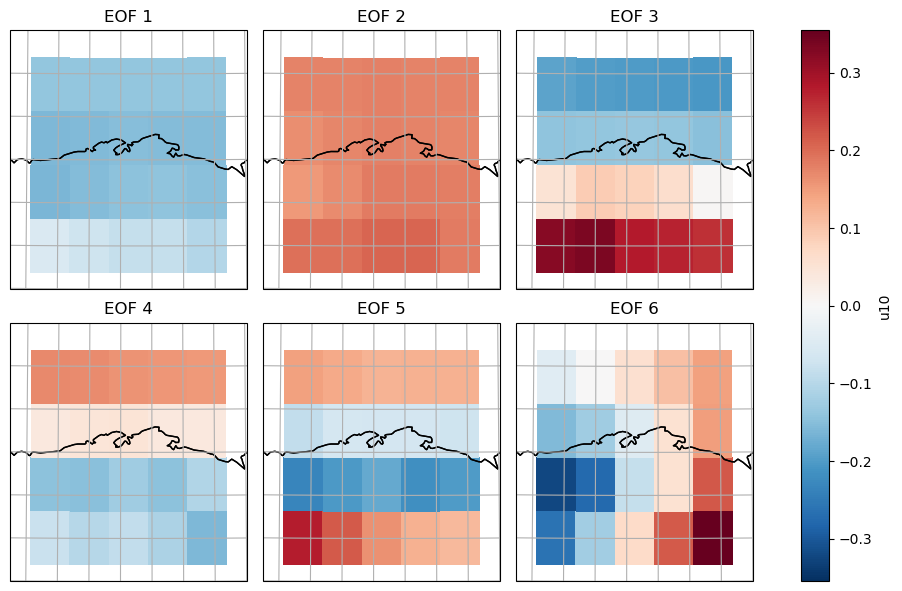

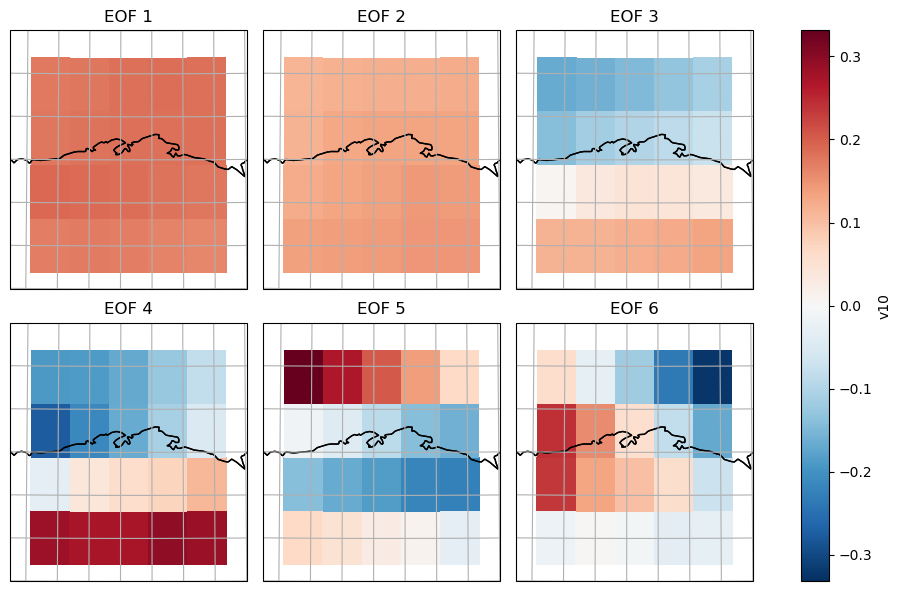

In [ ]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

pca.plot_eofs(vars_to_plot=["u10", "v10"], num_eofs=6, map_center=(-3.7, 43.5))

for num in plt.get_fignums():
    for ax in plt.figure(num).axes:
        if hasattr(ax, "set_extent"):  # salta el eje de la colorbar
            ax.set_extent([-4.5, -3.0, 42.8, 44.0], crs=ccrs.PlateCarree())
            ax.coastlines("10m")  # 110m por defecto es muy basto aqui

In [6]:
pca.save_model(f"{PCA_DIR}/pca_era5.pkl")

2026-08-27 10:48:33,530 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!


## MDA

Running SWAN for all 8,760 hours is not affordable, so MDA orders them by
dissimilarity and the first `NUM_TIMES` are simulated. Ten here is a
demonstration; the results in `03` onwards use 500.

In [7]:
mda = MDA(num_centers=len(pca.pcs_df))

mda.fit(
    data=pca.pcs_df,
    directional_variables=[],
)

In [8]:
times = pca.pcs_df.iloc[mda.centroid_real_indices][0:NUM_TIMES]
times

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
1984-10-04 09:00:00,7.653721,10.670355,1.585753,-1.788554,0.248161,0.263353,-0.556303,0.109192,0.894267,0.112464,-0.150338
1993-02-27 04:00:00,-7.594664,-8.697045,2.490298,0.459307,0.656710,-0.404028,0.672218,-0.588410,-0.011523,-0.064085,0.172519
1999-12-27 18:00:00,-12.665132,9.229034,0.121899,-1.799720,0.787764,-1.514619,-0.609177,1.115330,-0.254935,0.331351,-0.179904
2008-12-27 14:00:00,7.707611,-6.067432,-1.430144,1.547017,-0.608188,0.316929,-0.662104,0.258778,-0.119164,-0.153953,0.060163
1998-04-03 13:00:00,-2.290333,4.396352,7.011479,3.307407,0.620983,0.924361,-0.977984,-0.270039,-1.111955,0.295587,0.065602
2019-06-27 22:00:00,-2.197272,1.115026,-3.827985,-0.468678,-0.204551,0.245561,0.146478,0.725022,-0.392376,-0.175204,-0.303842
2009-01-24 02:00:00,-2.857096,13.956328,0.112547,-2.031954,1.946006,-0.900630,-0.696147,-0.409480,-0.812470,0.165959,0.230125
1982-11-06 21:00:00,13.061217,2.490377,-2.193546,0.654559,-1.404680,-0.101458,-1.371683,-0.707989,-0.482548,-0.155046,-0.100914
2019-02-02 04:00:00,-10.857292,0.612858,3.378762,-0.923091,-0.910014,0.716167,-0.449429,-0.318025,-0.179243,0.236999,0.136631
2006-11-24 16:00:00,6.123060,1.289779,4.183414,1.649244,0.465082,0.174998,-0.434547,1.010626,-0.424887,-0.015285,0.235532


## Save

In [9]:
np.savetxt(
    f"{TIMES_DIR}/times{NUM_TIMES}.txt",
    times.index.values.astype("datetime64[s]").astype(str),
    fmt="%s",
)

print(f"saved to {TIMES_DIR}/times{NUM_TIMES}.txt")

saved to outputs/SANTANDER/times/times10.txt
